<a href="https://colab.research.google.com/github/gustavomoyzzzzz/Entregas-Gustavo-Moya/blob/main/Tesis_infraestructura_electrica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Infraestructura de Carga Pública para Vehículos Eléctricos en la Región de Valparaíso

---

### Configuración inicial y carga de datos

In [ ]:
from datetime import date

# Variable editable para la fecha de corte del levantamiento (Punto 24 del requerimiento)
FECHA_CORTE_LEVANTAMIENTO = date(2024, 1, 31) # Ejemplo: 31 de enero de 2024

print(f"Fecha de corte del levantamiento: {FECHA_CORTE_LEVANTAMIENTO}")

### Upload your Excel file

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
  df = pd.read_excel(filename)
  print(f'Successfully loaded "{filename}" into a pandas DataFrame.')


display(df.head())

Saving Catastro_electrolineras_Valparaiso_dashboard.xlsx to Catastro_electrolineras_Valparaiso_dashboard (1).xlsx
User uploaded file "Catastro_electrolineras_Valparaiso_dashboard (1).xlsx" with length 261325 bytes
Successfully loaded "Catastro_electrolineras_Valparaiso_dashboard (1).xlsx" into a pandas DataFrame.


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor kWh,estado_normalizado,clasificacion operativa,cobertura nominal,cobertura efectiva
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No


### Revisión de la estructura inicial de los datos

In [66]:
# Mostrar las columnas originales (Punto 3 del requerimiento)
print("Columnas originales:\n", df.columns.tolist())

# Mostrar las primeras filas para revisar la estructura (Punto 3 del requerimiento)
display(df.head())

Columnas originales:
 ['nombre', 'region', 'comuna', 'direccion', 'latitud', 'longitud', 'potencia_electrolinera_(kw)', 'conectores.tipo', 'conectores.carga', 'potencia_cargador_(kw)', 'fecha_revision', 'estado', 'valor kWh', 'estado_normalizado', 'clasificacion operativa', 'cobertura nominal', 'cobertura efectiva ']


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor kWh,estado_normalizado,clasificacion operativa,cobertura nominal,cobertura efectiva
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No


### Normalización de nombres de columnas

In [67]:
# Normalizar los nombres de las columnas (Punto 4 del requerimiento)
def normalize_column_name(col_name):
    return col_name.strip().lower().replace(' ', '_').replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u').replace('ñ', 'n')

df.columns = [normalize_column_name(col) for col in df.columns]

print("Columnas normalizadas:\n", df.columns.tolist())
display(df.head())

Columnas normalizadas:
 ['nombre', 'region', 'comuna', 'direccion', 'latitud', 'longitud', 'potencia_electrolinera_(kw)', 'conectores.tipo', 'conectores.carga', 'potencia_cargador_(kw)', 'fecha_revision', 'estado', 'valor_kwh', 'estado_normalizado', 'clasificacion_operativa', 'cobertura_nominal', 'cobertura_efectiva']


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor_kwh,estado_normalizado,clasificacion_operativa,cobertura_nominal,cobertura_efectiva
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No


### Identificación de columnas clave

In [68]:
# Imprimir columnas disponibles para que el usuario pueda ajustar los nombres si es necesario (Punto 27 del requerimiento)
print("Columnas disponibles para identificar las claves:", df.columns.tolist())

# Definir manualmente las columnas clave (Punto 5 del requerimiento)
# Se asume que 'nombre', 'comuna', 'direccion', 'estado', 'potencia' y 'conector' siempre están presentes.
# 'operador', 'latitud', 'longitud' son opcionales y el código se adaptará si no existen (Punto 28 del requerimiento).

KEY_COL_NOMBRE_PUNTO = 'nombre'
KEY_COL_COMUNA = 'comuna'
KEY_COL_DIRECCION = 'direccion'
KEY_COL_ESTADO = 'estado'
KEY_COL_POTENCIA = 'potencia_cargador_(kw)' # Asumo que esta es la columna de potencia del conector
KEY_COL_CONECTOR = 'conectores.tipo' # Asumo que esta es la columna de tipo de conector

# Columnas opcionales
KEY_COL_OPERADOR = 'operador' if 'operador' in df.columns else None
KEY_COL_LATITUD = 'latitud' if 'latitud' in df.columns else None
KEY_COL_LONGITUD = 'longitud' if 'longitud' in df.columns else None

print("\nColumnas clave identificadas:")
print(f"- Nombre del punto: {KEY_COL_NOMBRE_PUNTO}")
print(f"- Comuna: {KEY_COL_COMUNA}")
print(f"- Dirección: {KEY_COL_DIRECCION}")
print(f"- Estado: {KEY_COL_ESTADO}")
print(f"- Potencia: {KEY_COL_POTENCIA}")
print(f"- Conector: {KEY_COL_CONECTOR}")
print(f"- Operador: {KEY_COL_OPERADOR if KEY_COL_OPERADOR else 'No encontrada'}")
print(f"- Latitud: {KEY_COL_LATITUD if KEY_COL_LATITUD else 'No encontrada'}")
print(f"- Longitud: {KEY_COL_LONGITUD if KEY_COL_LONGITUD else 'No encontrada'}")

Columnas disponibles para identificar las claves: ['nombre', 'region', 'comuna', 'direccion', 'latitud', 'longitud', 'potencia_electrolinera_(kw)', 'conectores.tipo', 'conectores.carga', 'potencia_cargador_(kw)', 'fecha_revision', 'estado', 'valor_kwh', 'estado_normalizado', 'clasificacion_operativa', 'cobertura_nominal', 'cobertura_efectiva']

Columnas clave identificadas:
- Nombre del punto: nombre
- Comuna: comuna
- Dirección: direccion
- Estado: estado
- Potencia: potencia_cargador_(kw)
- Conector: conectores.tipo
- Operador: No encontrada
- Latitud: latitud
- Longitud: longitud


### Limpieza y normalización de la columna 'estado'

In [69]:
# Limpiar y normalizar la columna de estado (Punto 6 del requerimiento)
def clean_estado(estado):
    if pd.isna(estado):
        return 'No verificable'
    estado_lower = str(estado).lower()
    if 'disponible' in estado_lower:
        return 'Disponible'
    elif 'fuera de linea' in estado_lower or 'fuera de línea' in estado_lower:
        return 'Fuera de línea'
    elif 'no disponible' in estado_lower:
        return 'No disponible'
    else:
        return 'No verificable'

df['estado_normalizado'] = df[KEY_COL_ESTADO].apply(clean_estado)

print("Valores únicos en la columna 'estado_normalizado':")
print(df['estado_normalizado'].value_counts())
display(df.head())

Valores únicos en la columna 'estado_normalizado':
estado_normalizado
Disponible        88
Fuera de línea    39
Name: count, dtype: int64


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor_kwh,estado_normalizado,clasificacion_operativa,cobertura_nominal,cobertura_efectiva
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea,Sí,No


### Creación de columnas de clasificación operativa y cobertura

In [73]:
# Crear una columna llamada “clasificacion_operativa” (Punto 7 del requerimiento)
def get_clasificacion_operativa(estado_normalizado):
    if estado_normalizado == 'Disponible':
        return 'Operativo'
    elif estado_normalizado == 'Fuera de línea':
        return 'Fuera de línea (temporal)' # Clarificado como temporal
    elif estado_normalizado == 'No disponible':
        return 'No operativo (no vigente)' # Nueva clasificación para no disponibles
    else:
        return 'No verificable'

df['clasificacion_operativa'] = df['estado_normalizado'].apply(get_clasificacion_operativa)

# Crear una columna “cobertura_nominal_conector” (Punto 8 del requerimiento)
df['cobertura_nominal_conector'] = 'Sí'

# Crear una columna “cobertura_efectiva_conector” (Punto 9 del requerimiento)
df['cobertura_efectiva_conector'] = df['estado_normalizado'].apply(lambda x: 'Sí' if x == 'Disponible' else 'No')

print("Valores únicos en la columna 'clasificacion_operativa':")
print(df['clasificacion_operativa'].value_counts())
print("\nValores únicos en la columna 'cobertura_nominal_conector':")
print(df['cobertura_nominal_conector'].value_counts())
print("\nValores únicos en la columna 'cobertura_efectiva_conector':")
print(df['cobertura_efectiva_conector'].value_counts())
display(df.head())

Valores únicos en la columna 'clasificacion_operativa':
clasificacion_operativa
Operativo                    88
Fuera de línea (temporal)    39
Name: count, dtype: int64

Valores únicos en la columna 'cobertura_nominal_conector':
cobertura_nominal_conector
Sí    127
Name: count, dtype: int64

Valores únicos en la columna 'cobertura_efectiva_conector':
cobertura_efectiva_conector
Sí    88
No    39
Name: count, dtype: int64


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor_kwh,estado_normalizado,clasificacion_operativa,cobertura_nominal,cobertura_efectiva,cobertura_nominal_conector,cobertura_efectiva_conector
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No


### Regenerando `puntos_unicos`, KPIs, resúmenes y visualizaciones con la clasificación operativa corregida

In [74]:
# Re-crear un identificador de punto único (Punto 11 del requerimiento) con la lógica actualizada
id_cols = [KEY_COL_NOMBRE_PUNTO, KEY_COL_COMUNA, KEY_COL_DIRECCION]
if KEY_COL_LATITUD and KEY_COL_LONGITUD:
    id_cols.extend([KEY_COL_LATITUD, KEY_COL_LONGITUD])

for col in id_cols:
    if col not in base_conectores.columns:
        print(f"Advertencia: La columna '{col}' no se encuentra en el DataFrame 'base_conectores'. Se omitirá de la agrupación.")
        id_cols.remove(col)

puntos_unicos = base_conectores.groupby(id_cols).agg(
    total_conectores=('nombre', 'size'), # Número total de conectores/cargadores asociados (Punto 13)
    lista_potencias=(KEY_COL_POTENCIA, lambda x: list(x.unique())), # Lista de potencias presentes (Punto 13)
    lista_conectores=(KEY_COL_CONECTOR, lambda x: list(x.unique())), # Lista de conectores presentes (Punto 13)
    estados_presentes=('estado_normalizado', lambda x: list(x.unique())), # Estados presentes (Punto 13)
    operador=(KEY_COL_OPERADOR, lambda x: x.mode()[0] if not x.mode().empty else None) if KEY_COL_OPERADOR else (KEY_COL_NOMBRE_PUNTO, lambda x: None) # Operador si existe (Punto 13)
).reset_index()

puntos_unicos.rename(columns={'nombre': KEY_COL_NOMBRE_PUNTO}, inplace=True, errors='ignore')
puntos_unicos['id_punto'] = puntos_unicos.index + 1
puntos_unicos = puntos_unicos[['id_punto'] + id_cols + [col for col in puntos_unicos.columns if col not in ['id_punto'] + id_cols]]

def get_estado_final_punto_updated(estados_list):
    # Prioridad: Disponible > Fuera de línea (temporal) > No operativo (no vigente) > No verificable
    if 'Disponible' in estados_list:
        return 'Disponible'
    elif 'Fuera de línea' in estados_list: # Originalmente 'Fuera de línea', ahora se remapeará a 'Fuera de línea (temporal)' en la 'clasificacion_operativa'
        return 'Fuera de línea' # Mantener para consistencia con la columna 'estado_final_punto' si se desea un estado conciso
    elif 'No disponible' in estados_list:
        return 'No disponible' # Se remapeará a 'No operativo (no vigente)' en 'clasificacion_operativa'
    else:
        return 'No verificable'

puntos_unicos['estado_final_punto'] = puntos_unicos['estados_presentes'].apply(get_estado_final_punto_updated)

# Aplicar la nueva clasificación operativa a los puntos ónicos también
puntos_unicos['clasificacion_operativa_punto'] = puntos_unicos['estado_final_punto'].apply(get_clasificacion_operativa)

puntos_unicos['cobertura_nominal_punto'] = 'Sí'
puntos_unicos['cobertura_efectiva_punto'] = puntos_unicos['estado_final_punto'].apply(lambda x: 'Sí' if x == 'Disponible' else 'No')

print(f"'puntos_unicos' re-creada con {len(puntos_unicos)} puntos ónicos y lógica actualizada.")
display(puntos_unicos.head())

'puntos_unicos' re-creada con 36 puntos ónicos y lógica actualizada.


,id_punto,nombre,comuna,direccion,latitud,longitud,total_conectores,lista_potencias,lista_conectores,estados_presentes,operador,estado_final_punto,clasificacion_operativa_punto,cobertura_nominal_punto,cobertura_efectiva_punto
0,1,BMW-VIÑA DEL MAR,Vina del Mar,LIBERTAD 841,-33.013893,-71.550005,1,[7.4],[AC-Tipo 2 (Menneke)],[Fuera de línea],None,Fuera de línea,Fuera de línea (temporal),Sí,No
1,2,Boulevard Marina,Vina del Mar,Libertad 1348,-33.009169,-71.548502,2,[7.0],"[AC-Tipo 1 (SAE J1772), AC-Tipo 2 (Menneke)]",[Fuera de línea],None,Fuera de línea,Fuera de línea (temporal),Sí,No
2,3,COPEC 40046 VOLTEX EDS CONCÓN,Vina del Mar,AV. EDMUNDO ELUCHANS 3100,-32.949509,-71.544089,3,"[22.0, 180.0]","[AC-Tipo 2 (Menneke), CCS Tipo 2]","[Fuera de línea, Disponible]",None,Disponible,Operativo,Sí,Sí
3,4,COPEC 40059 Marbella,Puchuncaví,Ruta F30E Lote CC4 S/N,-32.671447,-71.425912,4,[180.0],[CCS Tipo 2],[Disponible],None,Disponible,Operativo,Sí,Sí
4,5,COPEC 40560,Llaillay,Panamericana Norte Km 90 Ruta 5 Poniente S/N,-32.842348,-71.003092,4,[500.0],[CCS Tipo 2],[Disponible],None,Disponible,Operativo,Sí,Sí


In [75]:
# Re-crear una tabla de KPIs principales (Punto 16 del requerimiento) con la lógica actualizada

total_registros_conectores = len(base_conectores)
total_puntos_unicos = len(puntos_unicos)

puntos_cobertura_efectiva = puntos_unicos[puntos_unicos['cobertura_efectiva_punto'] == 'Sí']
total_puntos_con_cobertura_efectiva = len(puntos_cobertura_efectiva)
total_puntos_sin_cobertura_efectiva = total_puntos_unicos - total_puntos_con_cobertura_efectiva

total_puntos_fuera_de_linea = len(puntos_unicos[puntos_unicos['clasificacion_operativa_punto'] == 'Fuera de línea (temporal)'])
total_puntos_no_operativos = len(puntos_unicos[puntos_unicos['clasificacion_operativa_punto'] == 'No operativo (no vigente)'])
total_puntos_no_verificables = len(puntos_unicos[puntos_unicos['clasificacion_operativa_punto'] == 'No verificable'])

porcentaje_cobertura_efectiva = (total_puntos_con_cobertura_efectiva / total_puntos_unicos) * 100 if total_puntos_unicos > 0 else 0
porcentaje_fuera_cobertura_efectiva = 100 - porcentaje_cobertura_efectiva

total_comunas = base_conectores[KEY_COL_COMUNA].nunique()
comunas_con_cobertura_efectiva = puntos_cobertura_efectiva[KEY_COL_COMUNA].nunique()

kpis = {
    'Total de registros/conectores': total_registros_conectores,
    'Total de puntos ónicos registrados': total_puntos_unicos,
    'Total de puntos con cobertura efectiva': total_puntos_con_cobertura_efectiva,
    'Total de puntos sin cobertura efectiva': total_puntos_sin_cobertura_efectiva,
    'Total de puntos fuera de línea (temporal)': total_puntos_fuera_de_linea,
    'Total de puntos no operativos (no vigentes)': total_puntos_no_operativos,
    'Total de puntos no verificables': total_puntos_no_verificables,
    'Porcentaje de cobertura efectiva (%)': f'{porcentaje_cobertura_efectiva:.2f}%',
    'Porcentaje fuera de cobertura efectiva (%)': f'{porcentaje_fuera_cobertura_efectiva:.2f}%',
    'Total de comunas con al menos un punto registrado': total_comunas,
    'Total de comunas con cobertura efectiva': comunas_con_cobertura_efectiva
}

kpis_df = pd.DataFrame.from_dict(kpis, orient='index', columns=['Valor'])
display(kpis_df)

,Valor
Total de registros/conectores,127
Total de puntos ónicos registrados,36
Total de puntos con cobertura efectiva,22
Total de puntos sin cobertura efectiva,14
Total de puntos fuera de línea (temporal),12
Total de puntos no operativos (no vigentes),2
Total de puntos no verificables,0
Porcentaje de cobertura efectiva (%),61.11%
Porcentaje fuera de cobertura efectiva (%),38.89%
Total de comunas con al menos un punto registrado,13


In [76]:
# Re-crear un resumen por comuna (Punto 17 del requerimiento) con la lógica actualizada

resumen_comunal = puntos_unicos.groupby(KEY_COL_COMUNA).agg(
    puntos_registrados=('id_punto', 'count'),
    puntos_con_cobertura_efectiva=(('cobertura_efectiva_punto'), lambda x: (x == 'Sí').sum()),
    puntos_sin_cobertura_efectiva=(('cobertura_efectiva_punto'), lambda x: (x == 'No').sum()),
    puntos_fuera_de_linea=(('clasificacion_operativa_punto'), lambda x: (x == 'Fuera de línea (temporal)').sum()),
    puntos_no_operativos=(('clasificacion_operativa_punto'), lambda x: (x == 'No operativo (no vigente)').sum()),
    puntos_no_verificables=(('clasificacion_operativa_punto'), lambda x: (x == 'No verificable').sum())
).reset_index()

conectores_por_comuna = base_conectores.groupby(KEY_COL_COMUNA).size().reset_index(name='total_conectores_registros')
resumen_comunal = pd.merge(resumen_comunal, conectores_por_comuna, on=KEY_COL_COMUNA, how='left')

resumen_comunal['porcentaje_cobertura_efectiva_comunal'] = (resumen_comunal['puntos_con_cobertura_efectiva'] / resumen_comunal['puntos_registrados']) * 100

display(resumen_comunal.sort_values(by='porcentaje_cobertura_efectiva_comunal', ascending=False))

,comuna,puntos_registrados,puntos_con_cobertura_efectiva,puntos_sin_cobertura_efectiva,puntos_fuera_de_linea,puntos_no_operativos,puntos_no_verificables,total_conectores_registros,porcentaje_cobertura_efectiva_comunal
2,Hijuelas,2,2,0,0,0,0,5,100.000000
3,Llaillay,2,2,0,0,0,0,7,100.000000
12,Zapallar,1,1,0,0,0,0,3,100.000000
6,Quillota,2,2,0,0,0,0,6,100.000000
5,Puchuncaví,2,2,0,0,0,0,6,100.000000
9,Santo Domingo,1,1,0,0,0,0,3,100.000000
1,Concón,3,2,1,1,0,0,6,66.666667
10,Valparaíso,5,3,2,2,0,0,51,60.000000
11,Vina del Mar,12,7,5,5,0,0,28,58.333333
4,Los Andes,3,0,3,1,2,0,6,0.000000


In [77]:
# Re-crear un resumen por estado final del punto (Punto 18 del requerimiento) con la lógica actualizada
resumen_estado = puntos_unicos['clasificacion_operativa_punto'].value_counts().reset_index()
resumen_estado.columns = ['Clasificación Operativa del Punto', 'Cantidad de Puntos']
resumen_estado['Porcentaje'] = (resumen_estado['Cantidad de Puntos'] / resumen_estado['Cantidad de Puntos'].sum()) * 100
display(resumen_estado)

,Clasificación Operativa del Punto,Cantidad de Puntos,Porcentaje
0,Operativo,22,61.111111
1,Fuera de línea (temporal),12,33.333333
2,No operativo (no vigente),2,5.555556


In [78]:
# Re-crear un resumen por tipo de conector (Punto 19 del requerimiento) - no afectado por la lógica de estado

conectores_flat = base_conectores[KEY_COL_CONECTOR].explode()
resumen_conectores = conectores_flat.value_counts().reset_index()
resumen_conectores.columns = ['Tipo de Conector', 'Cantidad de Conectores']
resumen_conectores['Porcentaje'] = (resumen_conectores['Cantidad de Conectores'] / resumen_conectores['Cantidad de Conectores'].sum()) * 100
display(resumen_conectores)

,Tipo de Conector,Cantidad de Conectores,Porcentaje
0,CCS Tipo 2,70,55.118110
1,AC-Tipo 2 (Menneke),41,32.283465
2,CHAdeMO,10,7.874016
3,AC-Tipo 1 (SAE J1772),6,4.724409


In [79]:
# Re-crear un resumen por potencia (Punto 20 del requerimiento) - no afectado por la lógica de estado
resumen_potencia = base_conectores[KEY_COL_POTENCIA].value_counts().reset_index()
resumen_potencia.columns = ['Potencia (kW)', 'Cantidad de Conectores']
resumen_potencia['Porcentaje'] = (resumen_potencia['Cantidad de Conectores'] / resumen_potencia['Cantidad de Conectores'].sum()) * 100
display(resumen_potencia.sort_values(by='Potencia (kW)', ascending=True))

,Potencia (kW),Cantidad de Conectores,Porcentaje
13,1.4,2,1.574803
17,3.5,1,0.787402
8,7.0,6,4.724409
4,7.4,9,7.086614
0,22.0,21,16.535433
9,43.0,5,3.937008
12,44.0,2,1.574803
2,50.0,17,13.385827
7,60.0,7,5.511811
15,100.0,1,0.787402


### Visualizaciones con datos actualizados

/tmp/ipykernel_8178/2349115988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clasificación Operativa del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')


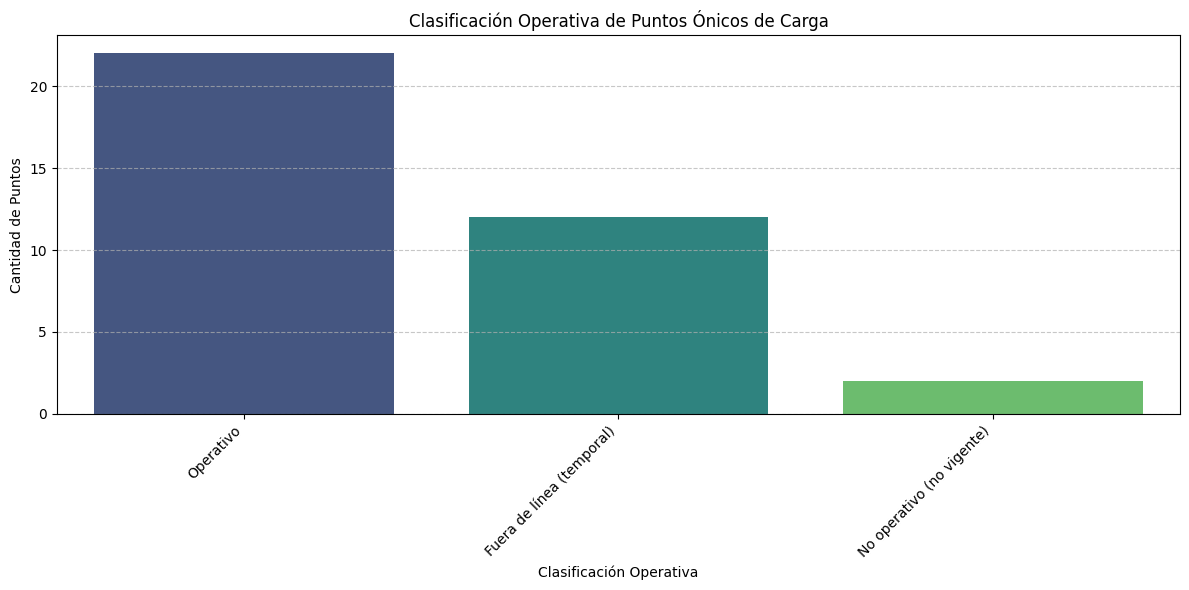

In [80]:
# Gráfico de barras con estado final de puntos ónicos (Punto 21a del requerimiento) con la lógica actualizada
plt.figure(figsize=(12, 6))
sns.barplot(x='Clasificación Operativa del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')
plt.title('Clasificación Operativa de Puntos Ónicos de Carga')
plt.xlabel('Clasificación Operativa')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

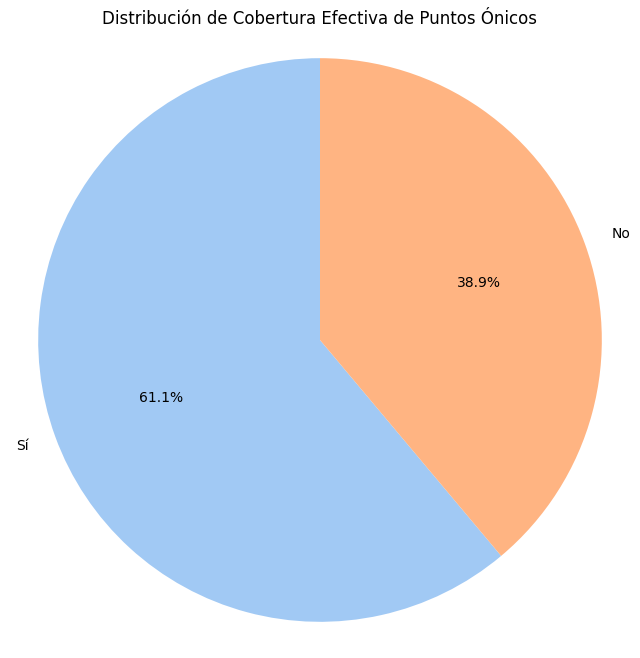

In [81]:
# Gráfico circular o de barras de cobertura efectiva (Punto 21b del requerimiento) con la lógica actualizada
cobertura_efectiva_summary = puntos_unicos['cobertura_efectiva_punto'].value_counts().reset_index()
cobertura_efectiva_summary.columns = ['Cobertura Efectiva', 'Cantidad']

plt.figure(figsize=(8, 8))
plt.pie(cobertura_efectiva_summary['Cantidad'], labels=cobertura_efectiva_summary['Cobertura Efectiva'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribución de Cobertura Efectiva de Puntos Ónicos')
plt.axis('equal')
plt.show()

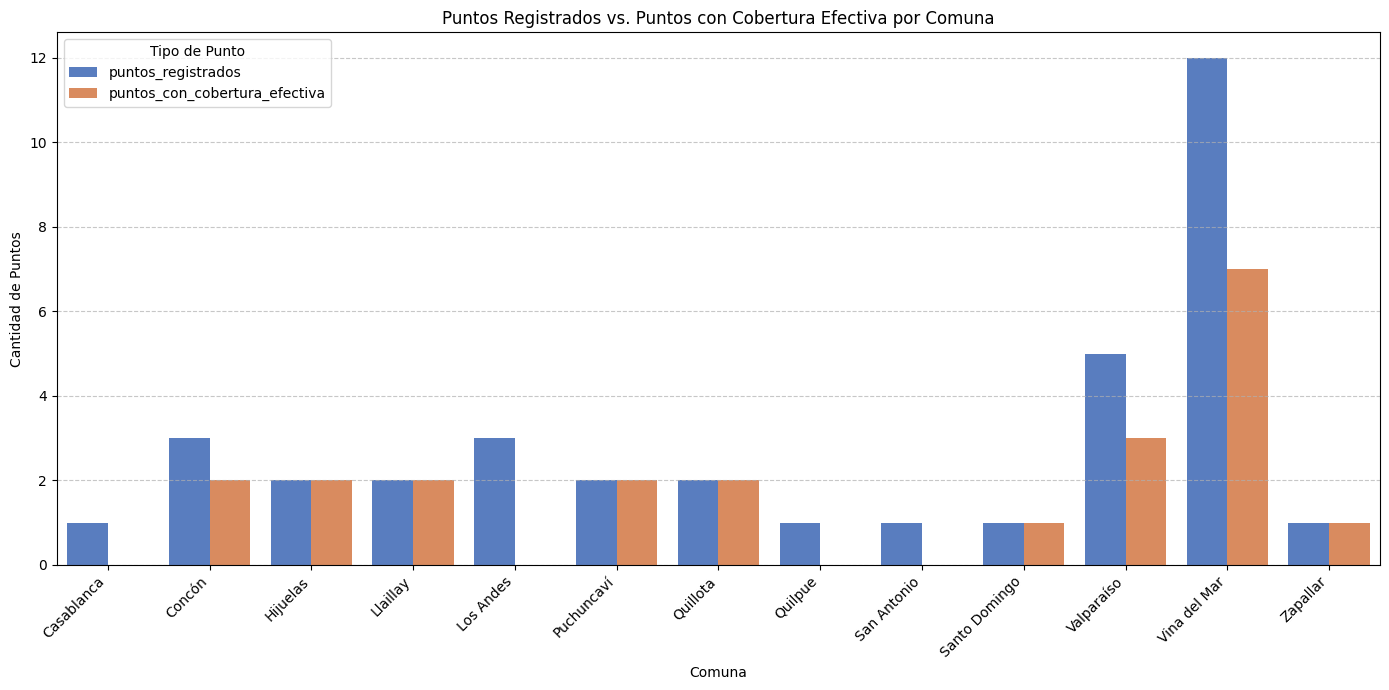

In [82]:
# Gráfico de barras con puntos registrados versus puntos efectivos por comuna (Punto 21c del requerimiento) con la lógica actualizada
resumen_comunal_melted = resumen_comunal.melt(id_vars=KEY_COL_COMUNA, value_vars=['puntos_registrados', 'puntos_con_cobertura_efectiva'], var_name='Tipo de Punto', value_name='Cantidad')

plt.figure(figsize=(14, 7))
sns.barplot(x=KEY_COL_COMUNA, y='Cantidad', hue='Tipo de Punto', data=resumen_comunal_melted, palette='muted')
plt.title('Puntos Registrados vs. Puntos con Cobertura Efectiva por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Punto')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8178/1368208563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')


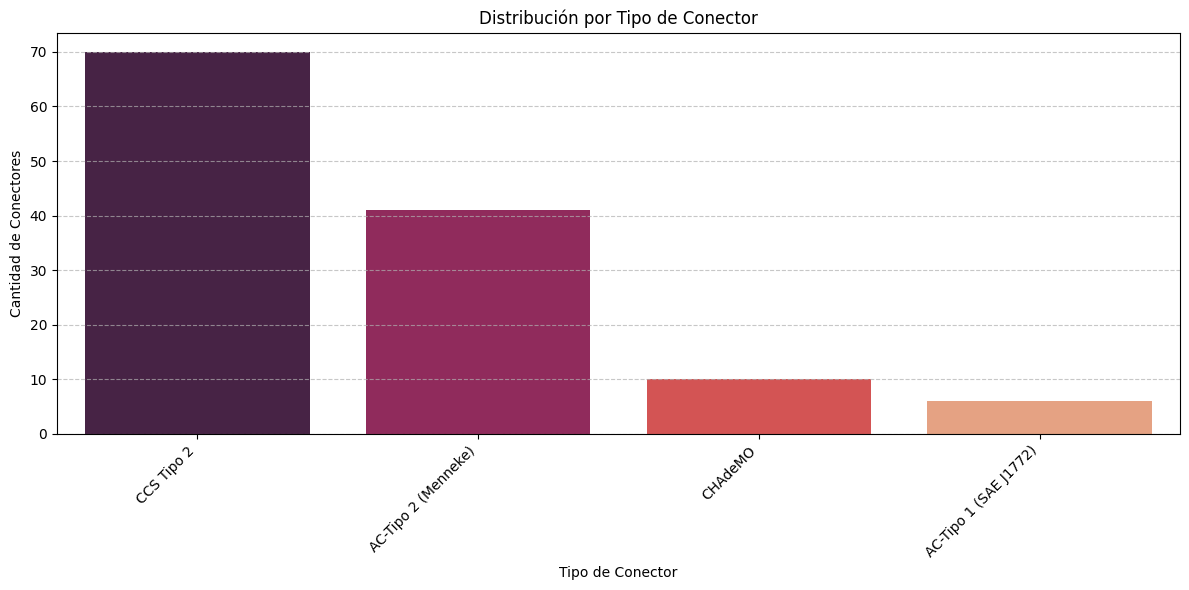

In [84]:
# Gráfico de barras con tipo de conector (Punto 21d del requerimiento) - no afectado por la lógica de estado
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')
plt.title('Distribución por Tipo de Conector')
plt.xlabel('Tipo de Conector')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8178/3217879965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')


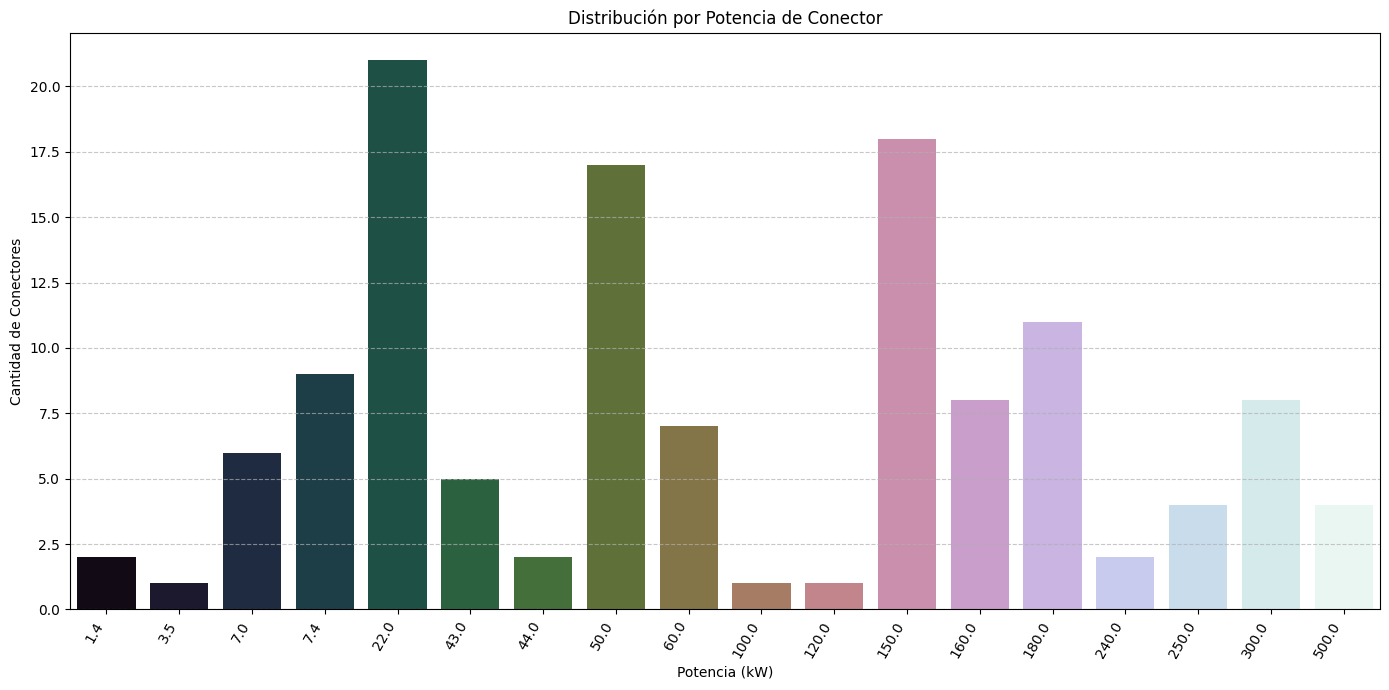

In [85]:
# Gráfico de barras con potencia (Punto 21e del requerimiento) - no afectado por la lógica de estado
plt.figure(figsize=(14, 7))
sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')
plt.title('Distribución por Potencia de Conector')
plt.xlabel('Potencia (kW)')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Re-guardando gráficos como imágenes para su inclusión en el archivo Excel.

In [86]:
# Guardar el gráfico de estado final de puntos ónicos (Punto 21a)
plt.figure(figsize=(12, 6))
sns.barplot(x='Clasificación Operativa del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')
plt.title('Clasificación Operativa de Puntos Ónicos de Carga')
plt.xlabel('Clasificación Operativa')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('estado_final_puntos_unicos.png')
plt.close() # Cerrar la figura para no mostrarla de nuevo en el notebook

/tmp/ipykernel_8178/707405734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Clasificación Operativa del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')


In [87]:
# Guardar el gráfico de distribución de cobertura efectiva (Punto 21b)
cobertura_efectiva_summary = puntos_unicos['cobertura_efectiva_punto'].value_counts().reset_index()
cobertura_efectiva_summary.columns = ['Cobertura Efectiva', 'Cantidad']

plt.figure(figsize=(8, 8))
plt.pie(cobertura_efectiva_summary['Cantidad'], labels=cobertura_efectiva_summary['Cobertura Efectiva'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribución de Cobertura Efectiva de Puntos Ónicos')
plt.axis('equal')
plt.tight_layout()
plt.savefig('distribucion_cobertura_efectiva.png')
plt.close()

In [88]:
# Guardar el gráfico de puntos registrados vs. efectivos por comuna (Punto 21c)
resumen_comunal_melted = resumen_comunal.melt(id_vars=KEY_COL_COMUNA, value_vars=['puntos_registrados', 'puntos_con_cobertura_efectiva'], var_name='Tipo de Punto', value_name='Cantidad')

plt.figure(figsize=(14, 7))
sns.barplot(x=KEY_COL_COMUNA, y='Cantidad', hue='Tipo de Punto', data=resumen_comunal_melted, palette='muted')
plt.title('Puntos Registrados vs. Puntos con Cobertura Efectiva por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Punto')
plt.tight_layout()
plt.savefig('puntos_comuna_registrados_efectivos.png')
plt.close()

In [89]:
# Guardar el gráfico de distribución por tipo de conector (Punto 21d)
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')
plt.title('Distribución por Tipo de Conector')
plt.xlabel('Tipo de Conector')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribucion_tipo_conector.png')
plt.close()

/tmp/ipykernel_8178/3926993406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')


In [90]:
# Guardar el gráfico de distribución por potencia (Punto 21e)
plt.figure(figsize=(14, 7))
sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')
plt.title('Distribución por Potencia de Conector')
plt.xlabel('Potencia (kW)')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribucion_potencia_conector.png')
plt.close()

/tmp/ipykernel_8178/4170652741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')


### Re-exportación a Excel y Diccionario Metodológico con datos actualizados

In [91]:
# Re-Exportar a Excel multifolio (Puntos 22-25 del requerimiento) con los datos y gráficos actualizados
output_filename = 'Catastro_electrolineras_Valparaiso_dashboard.xlsx'

with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    # Escribir cada DataFrame en una hoja diferente
    base_conectores.to_excel(writer, sheet_name='Base Conectores', index=False)
    puntos_unicos.to_excel(writer, sheet_name='Puntos Unicos', index=False)
    kpis_df.to_excel(writer, sheet_name='KPIs Principales') # No index para KPIs ya que el índice es la descripción
    resumen_comunal.to_excel(writer, sheet_name='Resumen Comunal', index=False)
    resumen_estado.to_excel(writer, sheet_name='Resumen Estado Punto', index=False)
    resumen_conectores.to_excel(writer, sheet_name='Resumen Conectores', index=False)
    resumen_potencia.to_excel(writer, sheet_name='Resumen Potencia', index=False)

    # Obtener el objeto workbook y worksheet de xlsxwriter
    workbook = writer.book

    # Insertar gráficos como imágenes (Punto 24 del requerimiento)
    chart_sheet_estado = workbook.add_worksheet('Grafico Estado Puntos')
    chart_sheet_estado.insert_image('A1', 'estado_final_puntos_unicos.png')

    chart_sheet_cobertura = workbook.add_worksheet('Grafico Cobertura Efectiva')
    chart_sheet_cobertura.insert_image('A1', 'distribucion_cobertura_efectiva.png')

    chart_sheet_comunas = workbook.add_worksheet('Grafico Puntos por Comuna')
    chart_sheet_comunas.insert_image('A1', 'puntos_comuna_registrados_efectivos.png')

    chart_sheet_conectores = workbook.add_worksheet('Grafico Tipo Conector')
    chart_sheet_conectores.insert_image('A1', 'distribucion_tipo_conector.png')

    chart_sheet_potencia = workbook.add_worksheet('Grafico Potencia Conector')
    chart_sheet_potencia.insert_image('A1', 'distribucion_potencia_conector.png')

print(f"El archivo '{output_filename}' ha sido generado exitosamente con los datos actualizados.")

El archivo 'Catastro_electrolineras_Valparaiso_dashboard.xlsx' ha sido generado exitosamente con los datos actualizados.


### Re-generando Mapa Interactivo con datos actualizados

In [92]:
import folium

# Filtrar puntos ónicos que tengan latitud y longitud disponibles
puntos_mapa = puntos_unicos.dropna(subset=[KEY_COL_LATITUD, KEY_COL_LONGITUD]).copy()

# Asegurarse de que las coordenadas son numéricas
puntos_mapa[KEY_COL_LATITUD] = pd.to_numeric(puntos_mapa[KEY_COL_LATITUD], errors='coerce')
puntos_mapa[KEY_COL_LONGITUD] = pd.to_numeric(puntos_mapa[KEY_COL_LONGITUD], errors='coerce')

puntos_mapa.dropna(subset=[KEY_COL_LATITUD, KEY_COL_LONGITUD], inplace=True)

if not puntos_mapa.empty:
    # Calcular el centro de los puntos para centrar el mapa
    center_lat = puntos_mapa[KEY_COL_LATITUD].mean()
    center_lon = puntos_mapa[KEY_COL_LONGITUD].mean()

    # Crear el mapa base centrado en la región de Valparaíso
    mapa_valparaiso = folium.Map(location=[center_lat, center_lon], zoom_start=10)

    # Añadir marcadores para cada punto de carga
    for idx, row in puntos_mapa.iterrows():
        # Definir el color del marcador basado en la clasificación operativa del punto
        if row['clasificacion_operativa_punto'] == 'Operativo':
            color = 'green'
        elif row['clasificacion_operativa_punto'] == 'Fuera de línea (temporal)':
            color = 'orange'
        elif row['clasificacion_operativa_punto'] == 'No operativo (no vigente)':
            color = 'red'
        else:
            color = 'gray'

        # Crear el texto del pop-up
        popup_html = f"""
            <b>Nombre:</b> {row[KEY_COL_NOMBRE_PUNTO]}<br>
            <b>Comuna:</b> {row[KEY_COL_COMUNA]}<br>
            <b>Dirección:</b> {row[KEY_COL_DIRECCION]}<br>
            <b>Estado:</b> {row['clasificacion_operativa_punto']}<br>
            <b>Total Conectores:</b> {row['total_conectores']}<br>
            <b>Potencias:</b> {', '.join(map(str, row['lista_potencias']))}<br>
            <b>Conectores:</b> {', '.join(map(str, row['lista_conectores']))}
        """

        folium.Marker(
            location=[row[KEY_COL_LATITUD], row[KEY_COL_LONGITUD]],
            popup=folium.Popup(popup_html, max_width=300),
            icon=folium.Icon(color=color, icon='bolt', prefix='fa')
        ).add_to(mapa_valparaiso)

    # Guardar el mapa como un archivo HTML
    map_filename = 'mapa_puntos_carga_valparaiso_updated.html'
    mapa_valparaiso.save(map_filename)

    print(f"El mapa interactivo ha sido generado y guardado como '{map_filename}' con los datos actualizados.")
    display(mapa_valparaiso)
else:
    print("No hay puntos de carga con coordenadas válidas para mostrar en el mapa.")

El mapa interactivo ha sido generado y guardado como 'mapa_puntos_carga_valparaiso_updated.html' con los datos actualizados.


### Creación de la base de conectores (`base_conectores`)

In [93]:
# Crear una base llamada “base_conectores”, manteniendo todos los registros originales (Punto 10 del requerimiento)
base_conectores = df.copy()

print(f"'base_conectores' creada con {len(base_conectores)} registros.")
display(base_conectores.head())

'base_conectores' creada con 127 registros.


,nombre,region,comuna,direccion,latitud,longitud,potencia_electrolinera_(kw),conectores.tipo,conectores.carga,potencia_cargador_(kw),fecha_revision,estado,valor_kwh,estado_normalizado,clasificacion_operativa,cobertura_nominal,cobertura_efectiva,cobertura_nominal_conector,cobertura_efectiva_conector
0,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
1,Edificio Chilquinta Barón,Valparaíso,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,22,AC-Tipo 2 (Menneke),AC,44.0,2019-05-09 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
2,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CHAdeMO,DC,50.0,2019-01-31 00:00:00,Disponible,395,Disponible,Operativo,Sí,Sí,Sí,Sí
3,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,CCS Tipo 2,DC,50.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No
4,COPEC Placilla 40098,Valparaíso,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,72,AC-Tipo 2 (Menneke),AC,43.0,2019-01-31 00:00:00,Fuera de linea,-,Fuera de línea,Fuera de línea (temporal),Sí,No,Sí,No


### Creación de identificadores de punto único y base `puntos_unicos`

In [94]:
# Crear un identificador de punto único (Punto 11 del requerimiento)
id_cols = [KEY_COL_NOMBRE_PUNTO, KEY_COL_COMUNA, KEY_COL_DIRECCION]
if KEY_COL_LATITUD and KEY_COL_LONGITUD:
    id_cols.extend([KEY_COL_LATITUD, KEY_COL_LONGITUD])

# Asegurarse de que las columnas clave existen en el DataFrame antes de agrupar
# Esto es una medida de seguridad, ya que las claves ya se definieron basándose en la existencia.
for col in id_cols:
    if col not in base_conectores.columns:
        print(f"Advertencia: La columna '{col}' no se encuentra en el DataFrame 'base_conectores'. Se omitirá de la agrupación.")
        id_cols.remove(col)

# Agrupar para crear puntos únicos (Punto 12 del requerimiento)
puntos_unicos = base_conectores.groupby(id_cols).agg(
    total_conectores=('nombre', 'size'), # Número total de conectores/cargadores asociados (Punto 13)
    lista_potencias=(KEY_COL_POTENCIA, lambda x: list(x.unique())), # Lista de potencias presentes (Punto 13)
    lista_conectores=(KEY_COL_CONECTOR, lambda x: list(x.unique())), # Lista de conectores presentes (Punto 13)
    estados_presentes=('estado_normalizado', lambda x: list(x.unique())), # Estados presentes (Punto 13)
    operador=(KEY_COL_OPERADOR, lambda x: x.mode()[0] if not x.mode().empty else None) if KEY_COL_OPERADOR else (KEY_COL_NOMBRE_PUNTO, lambda x: None) # Operador si existe (Punto 13)
).reset_index()

# Renombrar la columna 'nombre' si fue usada como base para el conteo de conectores
puntos_unicos.rename(columns={'nombre': KEY_COL_NOMBRE_PUNTO}, inplace=True, errors='ignore')

# Asignar un ID de punto único (Punto 13 del requerimiento)
puntos_unicos['id_punto'] = puntos_unicos.index + 1

# Reordenar columnas para tener 'id_punto' al inicio
# Asegurarse de que las columnas de id_cols estén al principio
puntos_unicos = puntos_unicos[['id_punto'] + id_cols + [col for col in puntos_unicos.columns if col not in ['id_punto'] + id_cols]]

# Criterio para estado final del punto (Punto 14 del requerimiento)
def get_estado_final_punto(estados_list):
    if 'Disponible' in estados_list:
        return 'Disponible'
    elif 'Fuera de línea' in estados_list:
        return 'Fuera de línea'
    elif 'No disponible' in estados_list:
        return 'No disponible'
    else:
        return 'No verificable'

puntos_unicos['estado_final_punto'] = puntos_unicos['estados_presentes'].apply(get_estado_final_punto)

# Criterio para cobertura nominal y efectiva del punto (Punto 13 y 15 del requerimiento)
puntos_unicos['cobertura_nominal_punto'] = 'Sí'
puntos_unicos['cobertura_efectiva_punto'] = puntos_unicos['estado_final_punto'].apply(lambda x: 'Sí' if x == 'Disponible' else 'No')

print(f"'puntos_unicos' creada con {len(puntos_unicos)} puntos únicos.")
display(puntos_unicos.head())

'puntos_unicos' creada con 36 puntos únicos.


,id_punto,nombre,comuna,direccion,latitud,longitud,total_conectores,lista_potencias,lista_conectores,estados_presentes,operador,estado_final_punto,cobertura_nominal_punto,cobertura_efectiva_punto
0,1,BMW-VIÑA DEL MAR,Vina del Mar,LIBERTAD 841,-33.013893,-71.550005,1,[7.4],[AC-Tipo 2 (Menneke)],[Fuera de línea],None,Fuera de línea,Sí,No
1,2,Boulevard Marina,Vina del Mar,Libertad 1348,-33.009169,-71.548502,2,[7.0],"[AC-Tipo 1 (SAE J1772), AC-Tipo 2 (Menneke)]",[Fuera de línea],None,Fuera de línea,Sí,No
2,3,COPEC 40046 VOLTEX EDS CONCÓN,Vina del Mar,AV. EDMUNDO ELUCHANS 3100,-32.949509,-71.544089,3,"[22.0, 180.0]","[AC-Tipo 2 (Menneke), CCS Tipo 2]","[Fuera de línea, Disponible]",None,Disponible,Sí,Sí
3,4,COPEC 40059 Marbella,Puchuncaví,Ruta F30E Lote CC4 S/N,-32.671447,-71.425912,4,[180.0],[CCS Tipo 2],[Disponible],None,Disponible,Sí,Sí
4,5,COPEC 40560,Llaillay,Panamericana Norte Km 90 Ruta 5 Poniente S/N,-32.842348,-71.003092,4,[500.0],[CCS Tipo 2],[Disponible],None,Disponible,Sí,Sí


### Creación de KPIs principales

In [95]:
# Crear una tabla de KPIs principales (Punto 16 del requerimiento)

total_registros_conectores = len(base_conectores)
total_puntos_unicos = len(puntos_unicos)

puntos_cobertura_efectiva = puntos_unicos[puntos_unicos['cobertura_efectiva_punto'] == 'Sí']
total_puntos_con_cobertura_efectiva = len(puntos_cobertura_efectiva)
total_puntos_sin_cobertura_efectiva = total_puntos_unicos - total_puntos_con_cobertura_efectiva

total_puntos_fuera_de_linea = len(puntos_unicos[puntos_unicos['estado_final_punto'] == 'Fuera de línea'])
total_puntos_no_disponibles = len(puntos_unicos[puntos_unicos['estado_final_punto'] == 'No disponible'])
total_puntos_no_verificables = len(puntos_unicos[puntos_unicos['estado_final_punto'] == 'No verificable'])

porcentaje_cobertura_efectiva = (total_puntos_con_cobertura_efectiva / total_puntos_unicos) * 100 if total_puntos_unicos > 0 else 0
porcentaje_fuera_cobertura_efectiva = 100 - porcentaje_cobertura_efectiva

total_comunas = base_conectores[KEY_COL_COMUNA].nunique()
comunas_con_cobertura_efectiva = puntos_cobertura_efectiva[KEY_COL_COMUNA].nunique()

kpis = {
    'Total de registros/conectores': total_registros_conectores,
    'Total de puntos únicos registrados': total_puntos_unicos,
    'Total de puntos con cobertura efectiva': total_puntos_con_cobertura_efectiva,
    'Total de puntos sin cobertura efectiva': total_puntos_sin_cobertura_efectiva,
    'Total de puntos fuera de línea': total_puntos_fuera_de_linea,
    'Total de puntos no disponibles': total_puntos_no_disponibles,
    'Total de puntos no verificables': total_puntos_no_verificables,
    'Porcentaje de cobertura efectiva (%)': f'{porcentaje_cobertura_efectiva:.2f}%',
    'Porcentaje fuera de cobertura efectiva (%)': f'{porcentaje_fuera_cobertura_efectiva:.2f}%',
    'Total de comunas con al menos un punto registrado': total_comunas,
    'Total de comunas con cobertura efectiva': comunas_con_cobertura_efectiva
}

kpis_df = pd.DataFrame.from_dict(kpis, orient='index', columns=['Valor'])
display(kpis_df)

,Valor
Total de registros/conectores,127
Total de puntos únicos registrados,36
Total de puntos con cobertura efectiva,24
Total de puntos sin cobertura efectiva,12
Total de puntos fuera de línea,12
Total de puntos no disponibles,0
Total de puntos no verificables,0
Porcentaje de cobertura efectiva (%),66.67%
Porcentaje fuera de cobertura efectiva (%),33.33%
Total de comunas con al menos un punto registrado,13


### Resumen por comuna

In [96]:
# Crear un resumen por comuna (Punto 17 del requerimiento)

resumen_comunal = puntos_unicos.groupby(KEY_COL_COMUNA).agg(
    puntos_registrados=('id_punto', 'count'),
    puntos_con_cobertura_efectiva=(('cobertura_efectiva_punto'), lambda x: (x == 'Sí').sum()),
    puntos_sin_cobertura_efectiva=(('cobertura_efectiva_punto'), lambda x: (x == 'No').sum()),
    puntos_fuera_de_linea=(('estado_final_punto'), lambda x: (x == 'Fuera de línea').sum()),
    puntos_no_disponibles=(('estado_final_punto'), lambda x: (x == 'No disponible').sum()),
    puntos_no_verificables=(('estado_final_punto'), lambda x: (x == 'No verificable').sum())
).reset_index()

# Unir con el conteo total de conectores por comuna desde base_conectores
conectores_por_comuna = base_conectores.groupby(KEY_COL_COMUNA).size().reset_index(name='total_conectores_registros')
resumen_comunal = pd.merge(resumen_comunal, conectores_por_comuna, on=KEY_COL_COMUNA, how='left')

resumen_comunal['porcentaje_cobertura_efectiva_comunal'] = (resumen_comunal['puntos_con_cobertura_efectiva'] / resumen_comunal['puntos_registrados']) * 100

display(resumen_comunal.sort_values(by='porcentaje_cobertura_efectiva_comunal', ascending=False))

,comuna,puntos_registrados,puntos_con_cobertura_efectiva,puntos_sin_cobertura_efectiva,puntos_fuera_de_linea,puntos_no_disponibles,puntos_no_verificables,total_conectores_registros,porcentaje_cobertura_efectiva_comunal
2,Hijuelas,2,2,0,0,0,0,5,100.000000
3,Llaillay,2,2,0,0,0,0,7,100.000000
12,Zapallar,1,1,0,0,0,0,3,100.000000
6,Quillota,2,2,0,0,0,0,6,100.000000
5,Puchuncaví,2,2,0,0,0,0,6,100.000000
9,Santo Domingo,1,1,0,0,0,0,3,100.000000
1,Concón,3,2,1,1,0,0,6,66.666667
4,Los Andes,3,2,1,1,0,0,6,66.666667
10,Valparaíso,5,3,2,2,0,0,51,60.000000
11,Vina del Mar,12,7,5,5,0,0,28,58.333333


### Resumen por estado final del punto

In [97]:
# Crear un resumen por estado final del punto (Punto 18 del requerimiento)
resumen_estado = puntos_unicos['estado_final_punto'].value_counts().reset_index()
resumen_estado.columns = ['Estado Final del Punto', 'Cantidad de Puntos']
resumen_estado['Porcentaje'] = (resumen_estado['Cantidad de Puntos'] / resumen_estado['Cantidad de Puntos'].sum()) * 100
display(resumen_estado)

,Estado Final del Punto,Cantidad de Puntos,Porcentaje
0,Disponible,24,66.666667
1,Fuera de línea,12,33.333333


### Resumen por tipo de conector

In [98]:
# Crear un resumen por tipo de conector (Punto 19 del requerimiento)

# Como 'lista_conectores' es una lista de strings, necesitamos 'explotarla' primero
conectores_flat = base_conectores[KEY_COL_CONECTOR].explode()
resumen_conectores = conectores_flat.value_counts().reset_index()
resumen_conectores.columns = ['Tipo de Conector', 'Cantidad de Conectores']
resumen_conectores['Porcentaje'] = (resumen_conectores['Cantidad de Conectores'] / resumen_conectores['Cantidad de Conectores'].sum()) * 100
display(resumen_conectores)

,Tipo de Conector,Cantidad de Conectores,Porcentaje
0,CCS Tipo 2,70,55.118110
1,AC-Tipo 2 (Menneke),41,32.283465
2,CHAdeMO,10,7.874016
3,AC-Tipo 1 (SAE J1772),6,4.724409


### Resumen por potencia

In [99]:
# Crear un resumen por potencia (Punto 20 del requerimiento)
resumen_potencia = base_conectores[KEY_COL_POTENCIA].value_counts().reset_index()
resumen_potencia.columns = ['Potencia (kW)', 'Cantidad de Conectores']
resumen_potencia['Porcentaje'] = (resumen_potencia['Cantidad de Conectores'] / resumen_potencia['Cantidad de Conectores'].sum()) * 100
display(resumen_potencia.sort_values(by='Potencia (kW)', ascending=True))

,Potencia (kW),Cantidad de Conectores,Porcentaje
13,1.4,2,1.574803
17,3.5,1,0.787402
8,7.0,6,4.724409
4,7.4,9,7.086614
0,22.0,21,16.535433
9,43.0,5,3.937008
12,44.0,2,1.574803
2,50.0,17,13.385827
7,60.0,7,5.511811
15,100.0,1,0.787402


### Visualizaciones

/tmp/ipykernel_8178/67232384.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estado Final del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')


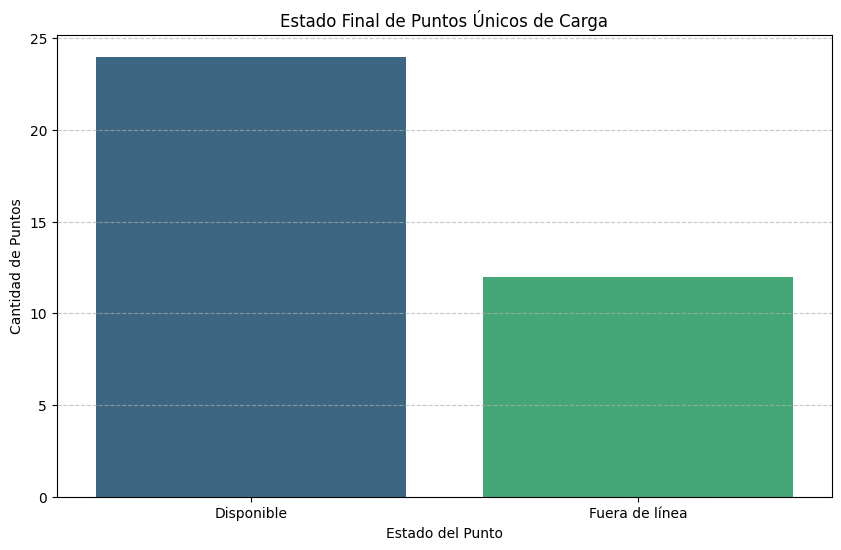

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de barras con estado final de puntos únicos (Punto 21a del requerimiento)
plt.figure(figsize=(10, 6))
sns.barplot(x='Estado Final del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')
plt.title('Estado Final de Puntos Únicos de Carga')
plt.xlabel('Estado del Punto')
plt.ylabel('Cantidad de Puntos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

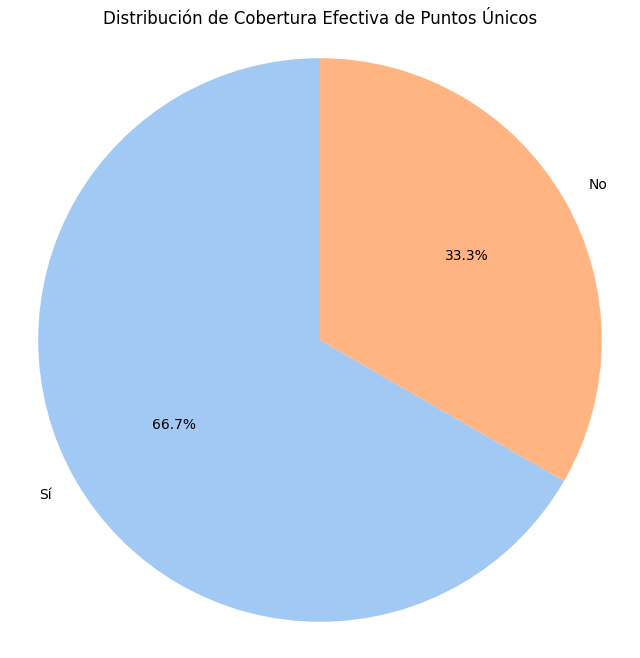

In [101]:
# Gráfico circular o de barras de cobertura efectiva (Punto 21b del requerimiento)
cobertura_efectiva_summary = puntos_unicos['cobertura_efectiva_punto'].value_counts().reset_index()
cobertura_efectiva_summary.columns = ['Cobertura Efectiva', 'Cantidad']

plt.figure(figsize=(8, 8))
plt.pie(cobertura_efectiva_summary['Cantidad'], labels=cobertura_efectiva_summary['Cobertura Efectiva'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribución de Cobertura Efectiva de Puntos Únicos')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

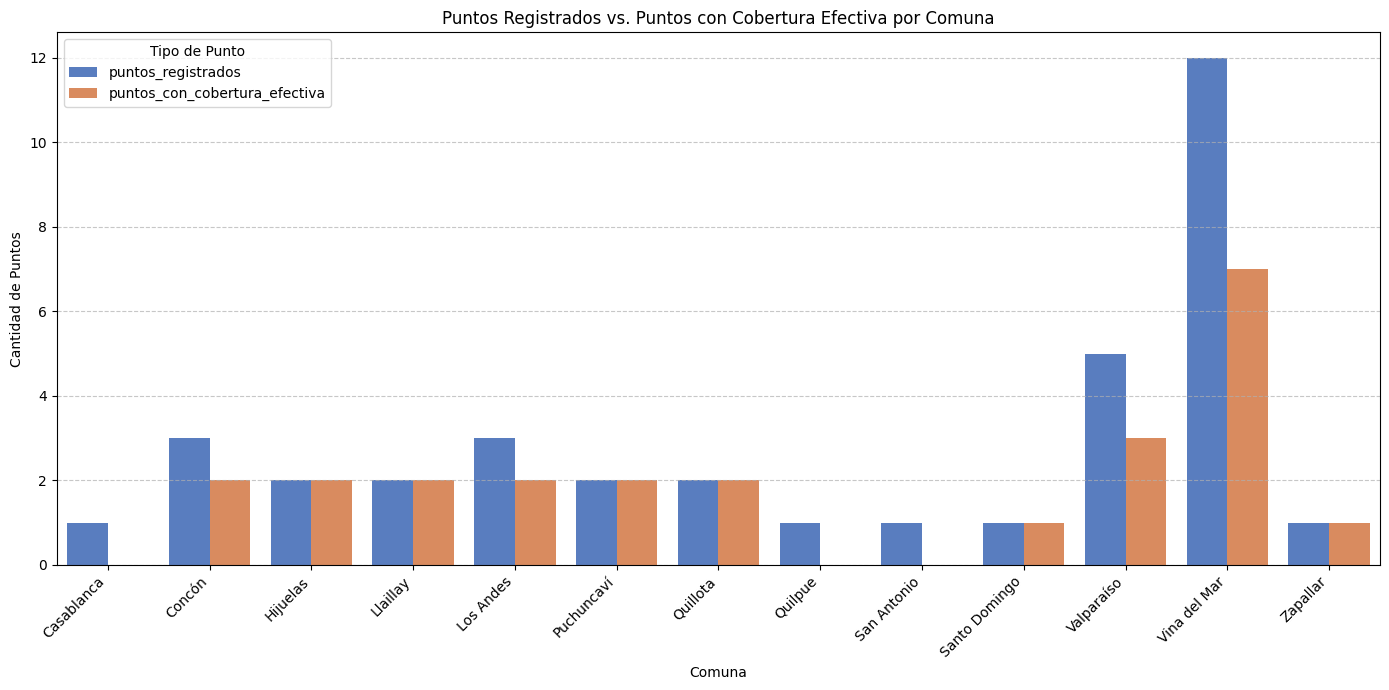

In [102]:
# Gráfico de barras con puntos registrados versus puntos efectivos por comuna (Punto 21c del requerimiento)
resumen_comunal_melted = resumen_comunal.melt(id_vars=KEY_COL_COMUNA, value_vars=['puntos_registrados', 'puntos_con_cobertura_efectiva'], var_name='Tipo de Punto', value_name='Cantidad')

plt.figure(figsize=(14, 7))
sns.barplot(x=KEY_COL_COMUNA, y='Cantidad', hue='Tipo de Punto', data=resumen_comunal_melted, palette='muted')
plt.title('Puntos Registrados vs. Puntos con Cobertura Efectiva por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Punto')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8178/2314097253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')


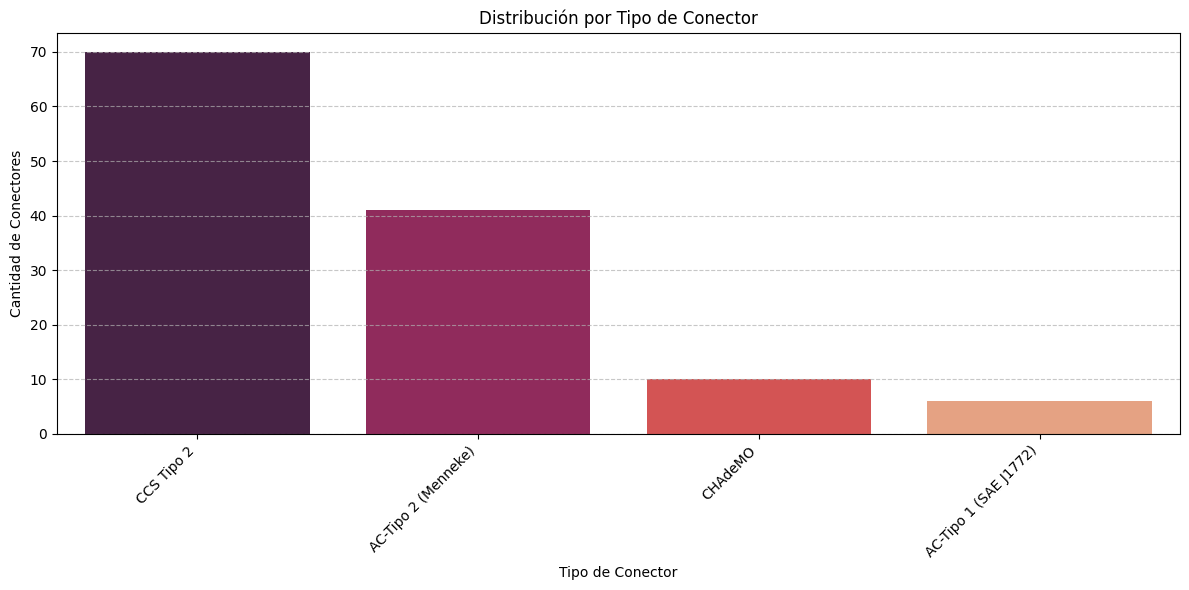

In [103]:
# Gráfico de barras con tipo de conector (Punto 21d del requerimiento)
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')
plt.title('Distribución por Tipo de Conector')
plt.xlabel('Tipo de Conector')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8178/1296877948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')


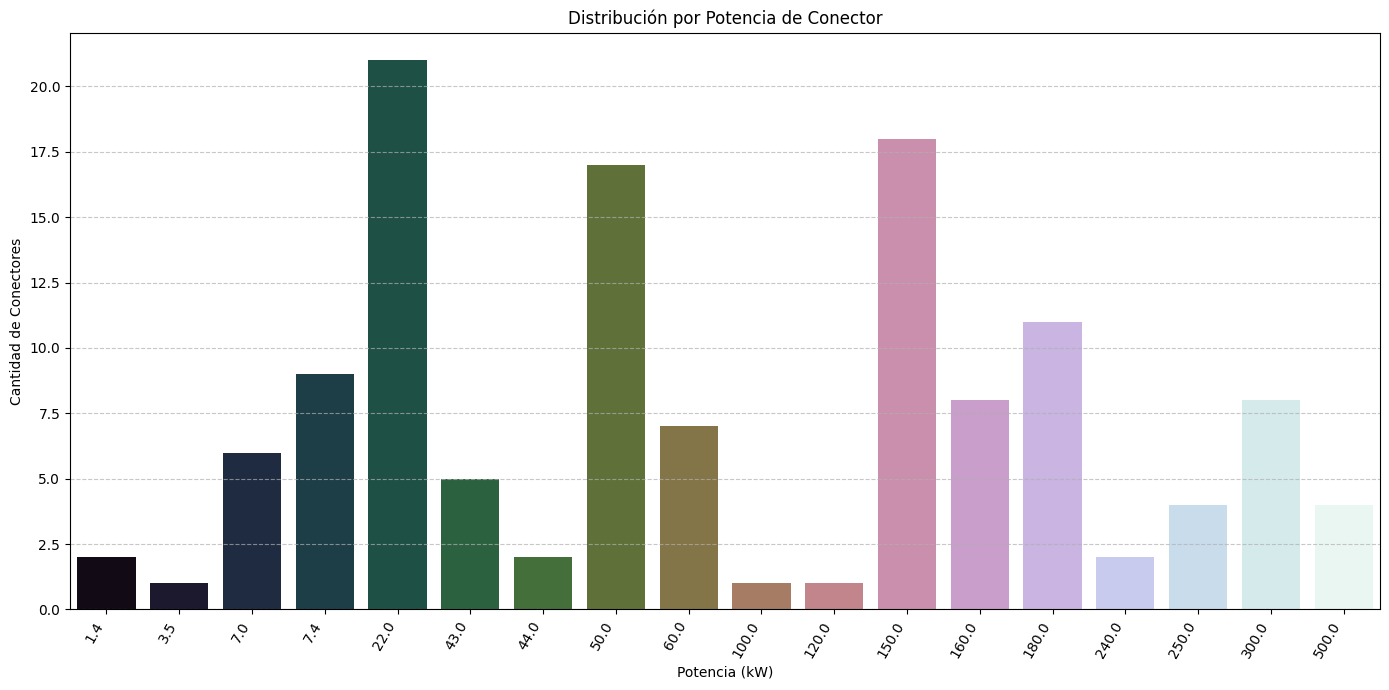

In [104]:
# Gráfico de barras con potencia (Punto 21e del requerimiento)
plt.figure(figsize=(14, 7))
sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')
plt.title('Distribución por Potencia de Conector')
plt.xlabel('Potencia (kW)')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exportación a Excel y Diccionario Metodológico

Guardando los gráficos generados como imágenes para su inclusión en el archivo Excel.

In [105]:
# Guardar el gráfico de estado final de puntos únicos (Punto 21a)
plt.figure(figsize=(10, 6))
sns.barplot(x='Estado Final del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')
plt.title('Estado Final de Puntos Únicos de Carga')
plt.xlabel('Estado del Punto')
plt.ylabel('Cantidad de Puntos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('estado_final_puntos_unicos.png')
plt.close() # Cerrar la figura para no mostrarla de nuevo en el notebook

/tmp/ipykernel_8178/2336301208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estado Final del Punto', y='Cantidad de Puntos', data=resumen_estado, palette='viridis')


In [106]:
# Guardar el gráfico de distribución de cobertura efectiva (Punto 21b)
cobertura_efectiva_summary = puntos_unicos['cobertura_efectiva_punto'].value_counts().reset_index()
cobertura_efectiva_summary.columns = ['Cobertura Efectiva', 'Cantidad']

plt.figure(figsize=(8, 8))
plt.pie(cobertura_efectiva_summary['Cantidad'], labels=cobertura_efectiva_summary['Cobertura Efectiva'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribución de Cobertura Efectiva de Puntos Únicos')
plt.axis('equal')
plt.tight_layout()
plt.savefig('distribucion_cobertura_efectiva.png')
plt.close()

In [107]:
# Guardar el gráfico de puntos registrados vs. efectivos por comuna (Punto 21c)
resumen_comunal_melted = resumen_comunal.melt(id_vars=KEY_COL_COMUNA, value_vars=['puntos_registrados', 'puntos_con_cobertura_efectiva'], var_name='Tipo de Punto', value_name='Cantidad')

plt.figure(figsize=(14, 7))
sns.barplot(x=KEY_COL_COMUNA, y='Cantidad', hue='Tipo de Punto', data=resumen_comunal_melted, palette='muted')
plt.title('Puntos Registrados vs. Puntos con Cobertura Efectiva por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Cantidad de Puntos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Punto')
plt.tight_layout()
plt.savefig('puntos_comuna_registrados_efectivos.png')
plt.close()

In [108]:
# Guardar el gráfico de distribución por tipo de conector (Punto 21d)
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')
plt.title('Distribución por Tipo de Conector')
plt.xlabel('Tipo de Conector')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribucion_tipo_conector.png')
plt.close()

/tmp/ipykernel_8178/3926993406.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Conector', y='Cantidad de Conectores', data=resumen_conectores, palette='rocket')


In [109]:
# Guardar el gráfico de distribución por potencia (Punto 21e)
plt.figure(figsize=(14, 7))
sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')
plt.title('Distribución por Potencia de Conector')
plt.xlabel('Potencia (kW)')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('distribucion_potencia_conector.png')
plt.close()

/tmp/ipykernel_8178/4170652741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Potencia (kW)', y='Cantidad de Conectores', data=resumen_potencia.sort_values(by='Potencia (kW)', ascending=True), palette='cubehelix')


Ahora, generaremos el archivo Excel con múltiples hojas, incluyendo todas las bases de datos procesadas, los resúmenes y los KPIs. Los gráficos se añadirán como imágenes en hojas separadas.

In [110]:
# Exportar a Excel multifolio (Puntos 22-25 del requerimiento)
!pip install xlsxwriter
output_filename = 'Catastro_electrolineras_Valparaiso_dashboard.xlsx'

with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    # Escribir cada DataFrame en una hoja diferente
    base_conectores.to_excel(writer, sheet_name='Base Conectores', index=False)
    puntos_unicos.to_excel(writer, sheet_name='Puntos Unicos', index=False)
    kpis_df.to_excel(writer, sheet_name='KPIs Principales') # No index para KPIs ya que el índice es la descripción
    resumen_comunal.to_excel(writer, sheet_name='Resumen Comunal', index=False)
    resumen_estado.to_excel(writer, sheet_name='Resumen Estado Punto', index=False)
    resumen_conectores.to_excel(writer, sheet_name='Resumen Conectores', index=False)
    resumen_potencia.to_excel(writer, sheet_name='Resumen Potencia', index=False)

    # Obtener el objeto workbook y worksheet de xlsxwriter
    workbook = writer.book

    # Insertar gráficos como imágenes (Punto 24 del requerimiento)
    chart_sheet_estado = workbook.add_worksheet('Grafico Estado Puntos')
    chart_sheet_estado.insert_image('A1', 'estado_final_puntos_unicos.png')

    chart_sheet_cobertura = workbook.add_worksheet('Grafico Cobertura Efectiva')
    chart_sheet_cobertura.insert_image('A1', 'distribucion_cobertura_efectiva.png')

    chart_sheet_comunas = workbook.add_worksheet('Grafico Puntos por Comuna')
    chart_sheet_comunas.insert_image('A1', 'puntos_comuna_registrados_efectivos.png')

    chart_sheet_conectores = workbook.add_worksheet('Grafico Tipo Conector')
    chart_sheet_conectores.insert_image('A1', 'distribucion_tipo_conector.png')

    chart_sheet_potencia = workbook.add_worksheet('Grafico Potencia Conector')
    chart_sheet_potencia.insert_image('A1', 'distribucion_potencia_conector.png')

print(f"El archivo '{output_filename}' ha sido generado exitosamente.")

El archivo 'Catastro_electrolineras_Valparaiso_dashboard.xlsx' ha sido generado exitosamente.


### Diccionario Metodológico

Esta sección detalla la metodología utilizada para el procesamiento y análisis de los datos.

#### **Variables y Columnas Clave**

*   **`nombre`**: Nombre del punto de carga.
*   **`comuna`**: Comuna donde se encuentra el punto de carga.
*   **`direccion`**: Dirección exacta del punto de carga.
*   **`latitud` / `longitud`**: Coordenadas geográficas del punto (si disponibles).
*   **`estado`**: Estado original reportado del conector.
*   **`estado_normalizado`**: Estado del conector estandarizado a 'Disponible', 'Fuera de línea', 'No disponible', 'No verificable'.
*   **`clasificacion_operativa`**: Clasificación operativa del conector ('Operativo', 'Fuera de línea', 'No disponible', 'No verificable').
*   **`cobertura_nominal_conector`**: Indica si el conector tiene cobertura nominal ('Sí').
*   **`cobertura_efectiva_conector`**: Indica si el conector está efectivamente disponible ('Sí' si `estado_normalizado` es 'Disponible', 'No' en caso contrario).
*   **`potencia_cargador_(kw)`**: Potencia del cargador en kilovatios (kW).
*   **`conectores.tipo`**: Tipo de conector (ej., CCS Tipo 2, AC-Tipo 2).

#### **Bases de Datos Generadas**

*   **`base_conectores`**: DataFrame original con todas las columnas, incluyendo las de normalización de estado y clasificación de cobertura por conector.
*   **`puntos_unicos`**: DataFrame que agrupa los registros por puntos de carga únicos, conteniendo información consolidada por punto como el total de conectores, listas de potencias y tipos de conectores, estados presentes y la cobertura efectiva del punto.

#### **KPIs y Resúmenes**

*   **`KPIs Principales`**: Tabla resumen con métricas clave a nivel regional, como el total de registros, puntos únicos, porcentaje de cobertura efectiva, y cantidad de comunas con y sin cobertura.
*   **`Resumen Comunal`**: Resumen de puntos registrados y con cobertura efectiva por comuna, incluyendo porcentajes.
*   **`Resumen Estado Punto`**: Distribución de los puntos únicos según su estado final (Disponible, Fuera de línea, No disponible, No verificable).
*   **`Resumen Conectores`**: Conteo y distribución porcentual por tipo de conector.
*   **`Resumen Potencia`**: Conteo y distribución porcentual por potencia de conector.

#### **Criterios de Agregación**

*   **Identificador de Punto Único**: Un punto de carga se considera único basándose en la combinación de `nombre`, `comuna`, `direccion`, `latitud` y `longitud` (si estas últimas están disponibles).
*   **Estado Final del Punto**: Un punto es 'Disponible' si al menos uno de sus conectores está 'Disponible'. Si no hay conectores 'Disponible' pero sí 'Fuera de línea', se clasifica como 'Fuera de línea', y así sucesivamente.
*   **Cobertura Efectiva del Punto**: Un punto tiene 'Cobertura Efectiva' si su `estado_final_punto` es 'Disponible'.

## Análisis Técnico-Económico de la Infraestructura de Carga

### Limpieza y Categorización de la Columna de Potencia

In [111]:
import numpy as np

# Función para limpiar la columna de potencia y convertirla a número (Punto 2 del requerimiento)
def clean_potencia(potencia_str):
    if pd.isna(potencia_str):
        return np.nan
    try:
        # Eliminar 'kW', espacios y comas, luego convertir a float
        clean_str = str(potencia_str).replace('kW', '').replace(' ', '').replace(',', '.').strip()
        return float(clean_str)
    except ValueError:
        return np.nan

# Aplicar la función de limpieza a la columna de potencia
base_conectores['potencia_cargador_kw_clean'] = base_conectores[KEY_COL_POTENCIA].apply(clean_potencia)

print(f"Columna '{KEY_COL_POTENCIA}' limpiada y convertida a 'potencia_cargador_kw_clean'.")
display(base_conectores[[KEY_COL_POTENCIA, 'potencia_cargador_kw_clean']].head())

Columna 'potencia_cargador_(kw)' limpiada y convertida a 'potencia_cargador_kw_clean'.


,potencia_cargador_(kw),potencia_cargador_kw_clean
0,44.0,44.0
1,44.0,44.0
2,50.0,50.0
3,50.0,50.0
4,43.0,43.0


### Creación de Columnas de Categoría de Potencia y Tipología AgenciaSE

In [112]:
# Crear la columna 'categoria_potencia' (Punto 3 del requerimiento)
def get_categoria_potencia(potencia):
    if pd.isna(potencia):
        return 'Sin información'
    elif 0 <= potencia <= 7.4:
        return 'Carga lenta AC'
    elif 7.4 < potencia <= 22:
        return 'Carga semirrápida AC'
    elif 22 < potencia <= 60:
        return 'Carga rápida DC estándar'
    elif 60 < potencia <= 120:
        return 'Carga rápida DC alta'
    elif potencia > 120:
        return 'Carga ultrarrápida'
    else:
        return 'Sin información' # Para valores negativos o fuera de rango inesperados

base_conectores['categoria_potencia'] = base_conectores['potencia_cargador_kw_clean'].apply(get_categoria_potencia)

print("Distribución por 'categoria_potencia':")
print(base_conectores['categoria_potencia'].value_counts())
display(base_conectores[[KEY_COL_POTENCIA, 'potencia_cargador_kw_clean', 'categoria_potencia']].head())

Distribución por 'categoria_potencia':
categoria_potencia
Carga ultrarrápida          55
Carga rápida DC estándar    31
Carga semirrápida AC        21
Carga lenta AC              18
Carga rápida DC alta         2
Name: count, dtype: int64


,potencia_cargador_(kw),potencia_cargador_kw_clean,categoria_potencia
0,44.0,44.0,Carga rápida DC estándar
1,44.0,44.0,Carga rápida DC estándar
2,50.0,50.0,Carga rápida DC estándar
3,50.0,50.0,Carga rápida DC estándar
4,43.0,43.0,Carga rápida DC estándar


In [113]:
# Crear la columna 'tipologia_agenciase_referencial' (Punto 4 del requerimiento)
def get_tipologia_agenciase(potencia):
    if pd.isna(potencia):
        return 'Sin tipología'
    elif potencia <= 7.4:
        return 'Proyecto 7 kW AC'
    elif 7.4 < potencia <= 22:
        return 'Carga de destino AC / referencia 7 kW'
    elif 22 < potencia <= 60:
        return 'Proyecto 60 kW DC'
    elif 60 < potencia <= 120:
        return 'Proyecto 120 kW DC'
    elif potencia > 120:
        return 'Escenario avanzado sobre 120 kW'
    else:
        return 'Sin tipología'

base_conectores['tipologia_agenciase_referencial'] = base_conectores['potencia_cargador_kw_clean'].apply(get_tipologia_agenciase)

print("Distribución por 'tipologia_agenciase_referencial':")
print(base_conectores['tipologia_agenciase_referencial'].value_counts())
display(base_conectores[[KEY_COL_POTENCIA, 'potencia_cargador_kw_clean', 'categoria_potencia', 'tipologia_agenciase_referencial']].head())

Distribución por 'tipologia_agenciase_referencial':
tipologia_agenciase_referencial
Escenario avanzado sobre 120 kW          55
Proyecto 60 kW DC                        31
Carga de destino AC / referencia 7 kW    21
Proyecto 7 kW AC                         18
Proyecto 120 kW DC                        2
Name: count, dtype: int64


,potencia_cargador_(kw),potencia_cargador_kw_clean,categoria_potencia,tipologia_agenciase_referencial
0,44.0,44.0,Carga rápida DC estándar,Proyecto 60 kW DC
1,44.0,44.0,Carga rápida DC estándar,Proyecto 60 kW DC
2,50.0,50.0,Carga rápida DC estándar,Proyecto 60 kW DC
3,50.0,50.0,Carga rápida DC estándar,Proyecto 60 kW DC
4,43.0,43.0,Carga rápida DC estándar,Proyecto 60 kW DC


### Visualización de Categorías de Potencia y Tipología AgenciaSE

/tmp/ipykernel_8178/3028773779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='categoria_potencia', data=base_conectores, palette='magma', order=base_conectores['categoria_potencia'].value_counts().index)


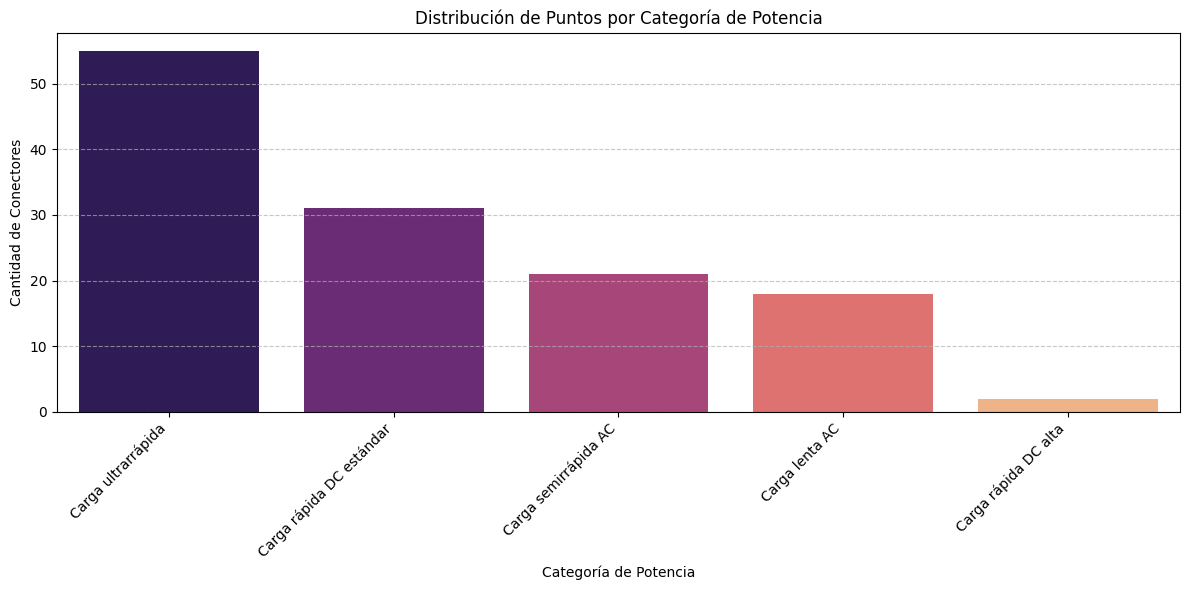

In [114]:
# Gráfico de barras para 'categoria_potencia'
plt.figure(figsize=(12, 6))
sns.countplot(x='categoria_potencia', data=base_conectores, palette='magma', order=base_conectores['categoria_potencia'].value_counts().index)
plt.title('Distribución de Puntos por Categoría de Potencia')
plt.xlabel('Categoría de Potencia')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8178/3123794588.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipologia_agenciase_referencial', data=base_conectores, palette='viridis', order=base_conectores['tipologia_agenciase_referencial'].value_counts().index)


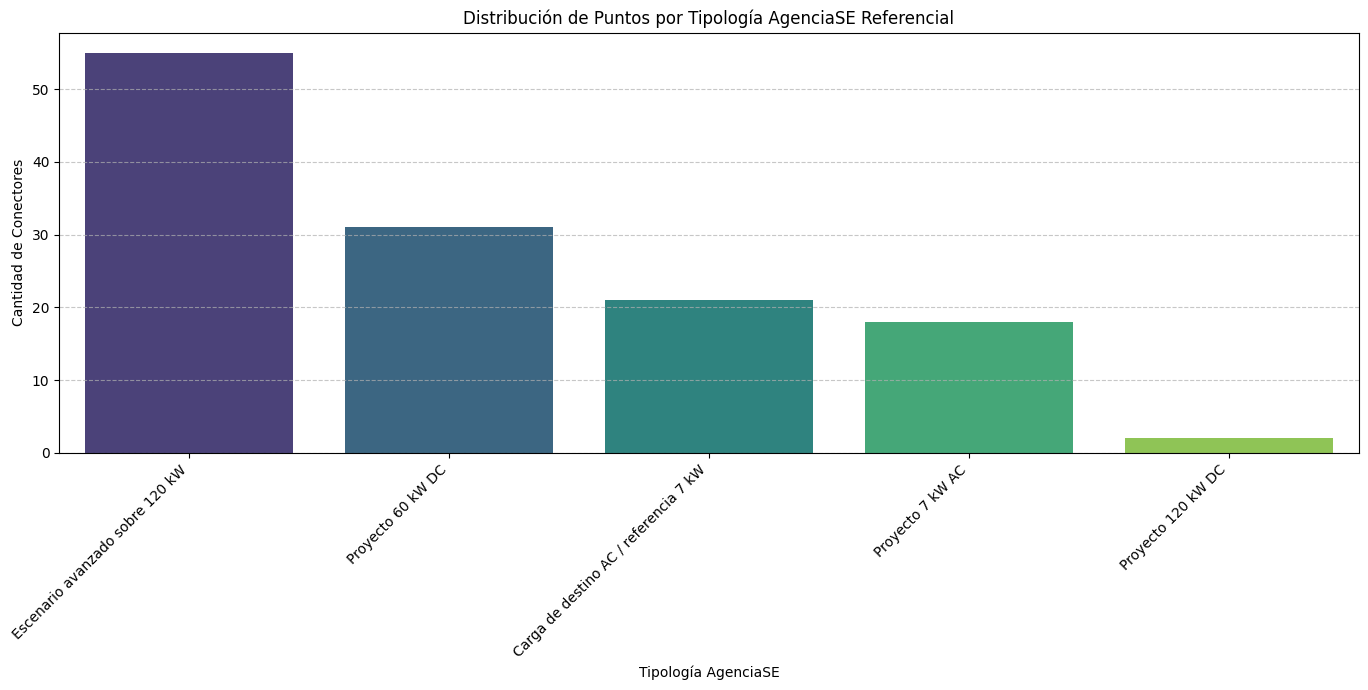

In [115]:
# Gráfico de barras para 'tipologia_agenciase_referencial'
plt.figure(figsize=(14, 7))
sns.countplot(x='tipologia_agenciase_referencial', data=base_conectores, palette='viridis', order=base_conectores['tipologia_agenciase_referencial'].value_counts().index)
plt.title('Distribución de Puntos por Tipología AgenciaSE Referencial')
plt.xlabel('Tipología AgenciaSE')
plt.ylabel('Cantidad de Conectores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualización de Puntos de Carga en el Mapa de la Región de Valparaíso

In [116]:
# Instalar folium si no está instalado
!pip install folium

In [117]:
import folium

# Filtrar puntos únicos que tengan latitud y longitud disponibles
puntos_mapa = puntos_unicos.dropna(subset=[KEY_COL_LATITUD, KEY_COL_LONGITUD]).copy()

# Asegurarse de que las coordenadas son numéricas
puntos_mapa[KEY_COL_LATITUD] = pd.to_numeric(puntos_mapa[KEY_COL_LATITUD], errors='coerce')
puntos_mapa[KEY_COL_LONGITUD] = pd.to_numeric(puntos_mapa[KEY_COL_LONGITUD], errors='coerce')

puntos_mapa.dropna(subset=[KEY_COL_LATITUD, KEY_COL_LONGITUD], inplace=True)

if not puntos_mapa.empty:
    # Calcular el centro de los puntos para centrar el mapa
    center_lat = puntos_mapa[KEY_COL_LATITUD].mean()
    center_lon = puntos_mapa[KEY_COL_LONGITUD].mean()

    # Crear el mapa base centrado en la región de Valparaíso
    mapa_valparaiso = folium.Map(location=[center_lat, center_lon], zoom_start=10)

    # Añadir marcadores para cada punto de carga
    for idx, row in puntos_mapa.iterrows():
        # Definir el color del marcador basado en el estado final del punto
        if row['estado_final_punto'] == 'Disponible':
            color = 'green'
        elif row['estado_final_punto'] == 'Fuera de línea':
            color = 'red'
        else:
            color = 'gray'

        # Crear el texto del pop-up
        popup_html = f"""
            <b>Nombre:</b> {row[KEY_COL_NOMBRE_PUNTO]}<br>
            <b>Comuna:</b> {row[KEY_COL_COMUNA]}<br>
            <b>Dirección:</b> {row[KEY_COL_DIRECCION]}<br>
            <b>Estado:</b> {row['estado_final_punto']}<br>
            <b>Total Conectores:</b> {row['total_conectores']}<br>
            <b>Potencias:</b> {', '.join(map(str, row['lista_potencias']))}<br>
            <b>Conectores:</b> {', '.join(map(str, row['lista_conectores']))}
        """

        folium.Marker(
            location=[row[KEY_COL_LATITUD], row[KEY_COL_LONGITUD]],
            popup=folium.Popup(popup_html, max_width=300),
            icon=folium.Icon(color=color, icon='bolt', prefix='fa')
        ).add_to(mapa_valparaiso)

    # Guardar el mapa como un archivo HTML
    map_filename = 'mapa_puntos_carga_valparaiso.html'
    mapa_valparaiso.save(map_filename)

    print(f"El mapa interactivo ha sido generado y guardado como '{map_filename}'.")
    display(mapa_valparaiso)
else:
    print("No hay puntos de carga con coordenadas válidas para mostrar en el mapa.")

El mapa interactivo ha sido generado y guardado como 'mapa_puntos_carga_valparaiso.html'.


El mapa interactivo muestra los puntos de carga. Puedes hacer clic en cada marcador para ver más detalles. El archivo `mapa_puntos_carga_valparaiso.html` ha sido guardado y puedes abrirlo en cualquier navegador web o incrustarlo en tus presentaciones.